# Commercial Subtype Classification with Heights

This notebook retrains and evaluates the commercial subtype classifier after adding LoD2 building-height features.

**Input**
- Preprocessed commercial classification data with height features.
- Previously optimized model parameters and selected features.

**Output**
- Evaluated height-enhanced model and final trained classifier.

In [1]:
# Imports & Config

import numpy as np
import pandas as pd
import joblib
import os
import json
import warnings
import matplotlib.pyplot as plt
from sklearn.metrics import (classification_report, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay)
import xgboost as xgb
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.utils.class_weight import compute_sample_weight


import optuna

warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

np.random.seed(42)

ROOT_DIR  = '/fast/home/o-olajuyigbe/osm_project'
ML_DIR    = os.path.join(ROOT_DIR, 'data', 'ml_ready')
MODEL_DIR = os.path.join(ROOT_DIR, 'data', 'models')
os.makedirs(MODEL_DIR, exist_ok=True)

# Which hierarchical level to train — change this one line to switch levels
# Options: 'flat_l1', 'flat_l2', 'l0_res_binary', 'l1a_res_subtypes',
#          'l1b_ind_binary', 'l2a_ind_subtypes', 'l2b_comm_binary', 'l3a_comm_subtypes'
LEVEL = 'l3a_comm_subtypes'

print(f"Training level: {LEVEL}")

Training level: l3a_comm_subtypes


/fast/home/o-olajuyigbe/miniforge3/envs/osm_env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
EXPERIMENT="with_lod2_height"

HEIGHT_FEATURES=[
    "lod2_height_m",
    ]

# Correct height-specific files
train_path=os.path.join(ML_DIR,f"{LEVEL}_train_raw_height.pkl")
val_path=os.path.join(ML_DIR,f"{LEVEL}_val_raw_height.pkl")
test_path=os.path.join(ML_DIR,f"{LEVEL}_test_raw_height.pkl")
classes_path=os.path.join(ML_DIR,f"{LEVEL}_classes_height.pkl")

for path in [train_path,val_path,test_path,classes_path]:
    if not os.path.exists(path): raise FileNotFoundError(path)
    print(f"Found: {path}")

X_train_raw,y_train=joblib.load(train_path)
X_val_raw,y_val=joblib.load(val_path)
X_test_raw,y_test=joblib.load(test_path)
classes=joblib.load(classes_path)
n_classes = len(np.unique(y_train))

print("\nRaw height-split shapes:")
print(f"Train: {X_train_raw.shape}")
print(f"Val  : {X_val_raw.shape}")
print(f"Test : {X_test_raw.shape}")

print("\nHeight columns actually present:")
for col in HEIGHT_FEATURES:
    print(f"{col:<30}: train={col in X_train_raw.columns}, val={col in X_val_raw.columns}, test={col in X_test_raw.columns}")

missing={
    split:[c for c in HEIGHT_FEATURES if c not in X.columns]
    for split,X in [("train",X_train_raw),("val",X_val_raw),("test",X_test_raw)]
}
missing={k:v for k,v in missing.items() if v}

if missing:
    raise KeyError(
        f"Height files exist but do not contain the height columns: {missing}. "
        "Rerun the split-building and saving cells in the height preprocessing notebook."
    )

print("\nTrain height summary:")
display(X_train_raw[HEIGHT_FEATURES].describe().T)

Found: /fast/home/o-olajuyigbe/osm_project/data/ml_ready/l3a_comm_subtypes_train_raw_height.pkl
Found: /fast/home/o-olajuyigbe/osm_project/data/ml_ready/l3a_comm_subtypes_val_raw_height.pkl
Found: /fast/home/o-olajuyigbe/osm_project/data/ml_ready/l3a_comm_subtypes_test_raw_height.pkl
Found: /fast/home/o-olajuyigbe/osm_project/data/ml_ready/l3a_comm_subtypes_classes_height.pkl



Raw height-split shapes:
Train: (224171, 111)
Val  : (13166, 111)
Test : (26205, 111)

Height columns actually present:
lod2_height_m                 : train=True, val=True, test=True

Train height summary:


,count,mean,std,min,25%,50%,75%,max
lod2_height_m,208305.0,10.263096,6.105433,0.008,6.094,9.103,12.781,256.151


In [3]:
SELECTED_FEATURE_PATH=os.path.join(MODEL_DIR,f"{LEVEL}_feature_cols.pkl")

if not os.path.exists(SELECTED_FEATURE_PATH):
    raise FileNotFoundError(
        f"Previously selected feature list not found:\n{SELECTED_FEATURE_PATH}")

selected_features=list(joblib.load(SELECTED_FEATURE_PATH))

# Append the four LoD2 features without repeating any existing feature
feature_cols=list(dict.fromkeys(selected_features+HEIGHT_FEATURES))

print("\nFeature configuration:")
print(f"Previously selected features: {len(selected_features)}")
print(f"LoD2 features requested      : {len(HEIGHT_FEATURES)}")
print(f"Final model features         : {len(feature_cols)}")

# Check that every required feature exists in every split
split_frames={"train":X_train_raw, "validation":X_val_raw, "test":X_test_raw}

missing_by_split={
    split:[column for column in feature_cols if column not in frame.columns]
    for split,frame in split_frames.items()}

missing_by_split={split:columns for split,columns in missing_by_split.items() if columns}

if missing_by_split:
    for split,columns in missing_by_split.items():
        print(f"\nMissing from {split}:")
        print(columns)

    raise KeyError(
        "The raw ML split files do not contain all selected and LoD2 features. "
        "Rerun ML preprocessing after creating the height features.")

print("\nLoD2 features included:")
for column in HEIGHT_FEATURES:
    print(f"  {column}")


Feature configuration:
Previously selected features: 89
LoD2 features requested      : 1
Final model features         : 90

LoD2 features included:
  lod2_height_m


In [4]:
# Reduce the data strictly to selected features + height features
# ---------------------------------------------------------------------
X_train=X_train_raw[feature_cols].copy()
X_val=X_val_raw[feature_cols].copy()
X_test=X_test_raw[feature_cols].copy()

for column in HEIGHT_FEATURES[1:]:
    X_train[column]=X_train[column].astype("float32")
    X_val[column]=X_val[column].astype("float32")
    X_test[column]=X_test[column].astype("float32")

print("\nFinal datasets:")
print(f"X_train: {X_train.shape}")
print(f"X_val  : {X_val.shape}")
print(f"X_test : {X_test.shape}")


# Save the augmented feature list separately; do not overwrite the baseline
HEIGHT_FEATURE_PATH=os.path.join(
    MODEL_DIR,
    f"{LEVEL}_feature_cols_{EXPERIMENT}.pkl"
)
joblib.dump(feature_cols,HEIGHT_FEATURE_PATH)


Final datasets:
X_train: (224171, 90)
X_val  : (13166, 90)
X_test : (26205, 90)


['/fast/home/o-olajuyigbe/osm_project/data/models/l3a_comm_subtypes_feature_cols_with_lod2_height.pkl']

In [5]:
def evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, level):
    results = {}
    for split_name, X_sp, y_sp in [('val', X_val, y_val), ('test', X_test, y_test)]:
        y_pred = model.predict(X_sp).astype(int)
        report = classification_report(y_sp, y_pred, target_names=classes, output_dict=True)
        macro_f1 = f1_score(y_sp, y_pred, average='macro')
        weighted_f1 = f1_score(y_sp, y_pred, average='weighted')
        
        results[split_name] = {
            'macro_f1'   : round(macro_f1, 4),
            'weighted_f1': round(weighted_f1, 4),
            'report'     : report,
        }
        print(f"\n{model_name} — {split_name.upper()}")
        print(f"  Macro F1           : {macro_f1:.4f}")
        print(f"  Weighted F1        : {weighted_f1:.4f}")
        print(classification_report(y_sp, y_pred, target_names=classes, digits=4))

    # Confusion matrix on test 
    y_pred_test = model.predict(X_test).astype(int)

    cm = confusion_matrix(y_test, y_pred_test)
    fig, ax = plt.subplots(figsize=(max(6, n_classes), max(5, n_classes-1)))
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, colorbar=False)
    ax.set_title(f'{model_name} — {level} — Test Confusion Matrix')
    plt.tight_layout()
    plt.savefig(os.path.join(MODEL_DIR, f'{level}_{model_name}_confusion.png'), dpi=150)
    plt.show()

    return results

all_results = {}


In [6]:
OPTUNA_PATH=os.path.join(MODEL_DIR, f"{LEVEL}_best_hyperparameters.json")

if not os.path.exists(OPTUNA_PATH):
    raise FileNotFoundError(
        f"Saved Optuna parameters not found:\n{OPTUNA_PATH}")

MINORITY_BOOST_LGB = 4.523054101792367
MINORITY_BOOST_XGB = 3.378521516345765

with open(OPTUNA_PATH,"r") as file:
    saved_optuna=json.load(file)

best_lgb_params=saved_optuna["lightgbm"].copy()
best_xgb_params=saved_optuna["xgboost"].copy()

print("\nSaved Optuna parameters loaded:")
print("\nLightGBM:")
print(best_lgb_params)
print("\nXGBoost:")
print(best_xgb_params)

class_counts=pd.Series(y_train).value_counts().sort_values()
minority_indices=class_counts.index[:2].tolist()

print("\nTraining distribution:")
for idx,count in class_counts.items():
    print(f"{classes[idx]:<20}: {count:>8,} ({count/len(y_train)*100:>5.2f}%)")

print(f"\nMinority classes: {[classes[i] for i in minority_indices]}")


# Works if minority_boost happens to exist in the saved JSON
final_minority_boost_lgb=float(best_lgb_params.pop("minority_boost",MINORITY_BOOST_LGB))
final_minority_boost_xgb=float(best_xgb_params.pop("minority_boost",MINORITY_BOOST_XGB))

print("\nSaved Optuna parameters loaded.")
print(f"LightGBM minority boost: {final_minority_boost_lgb:.4f}")
print(f"XGBoost minority boost : {final_minority_boost_xgb:.4f}")

print("\nLightGBM model parameters:")
print(best_lgb_params)

print("\nXGBoost model parameters:")
print(best_xgb_params)

def get_sample_weights(y,minority_boost=1.0):
    weights=compute_sample_weight(class_weight="balanced",y=y).astype("float64")
    for idx in minority_indices:
        weights[y==idx]*=minority_boost
    return weights

final_sample_weights_lgb=get_sample_weights(y_train,minority_boost=final_minority_boost_lgb)
final_sample_weights_xgb=get_sample_weights(y_train,minority_boost=final_minority_boost_xgb)



Saved Optuna parameters loaded:

LightGBM:
{'learning_rate': 0.0641494399631944, 'num_leaves': 123, 'min_child_samples': 297, 'subsample': 0.6221786605328554, 'colsample_bytree': 0.5614522896420875, 'reg_alpha': 1.2576332057238964, 'reg_lambda': 0.0012479218862622272}

XGBoost:
{'learning_rate': 0.10476349921421853, 'max_depth': 8, 'subsample': 0.7108757967164997, 'colsample_bytree': 0.6178624408763592, 'alpha': 0.39511551018548574, 'lambda': 3.7999114265823315, 'gamma': 0.007884538984224995, 'min_child_weight': 17}

Training distribution:
accommodation       :   26,012 (11.60%)
food_drink          :   27,680 (12.35%)
office              :   47,026 (20.98%)
retail              :  123,453 (55.07%)

Minority classes: ['accommodation', 'food_drink']

Saved Optuna parameters loaded.
LightGBM minority boost: 4.5231
XGBoost minority boost : 3.3785

LightGBM model parameters:
{'learning_rate': 0.0641494399631944, 'num_leaves': 123, 'min_child_samples': 297, 'subsample': 0.6221786605328554, '

In [7]:
print(f"\n{'='*60}\nTRAINING UNIFIED MODELS ON FULL X_TRAIN\n{'='*60}")
trained_models = {}

# --- Train LightGBM ---
print("Training unified LightGBM...")
lgb_params = {
    'objective': 'multiclass', 'num_class': n_classes, 'metric': 'multi_logloss', 
    'boosting_type': 'gbdt', 'n_estimators': 15000, 
    'importance_type': 'gain', 'n_jobs': -1, 'random_state': 42, 'verbosity': -1,
    **best_lgb_params
}
model_lgb = lgb.LGBMClassifier(**lgb_params)
model_lgb.fit(
    X_train, y_train,
    sample_weight=final_sample_weights_lgb,   
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(100, verbose=False), lgb.log_evaluation(200)]
)
save_path_lgb = os.path.join(MODEL_DIR, f'{LEVEL}_lightgbm_optimized_height.pkl')
joblib.dump(model_lgb, save_path_lgb)
trained_models['lightgbm'] = model_lgb

# --- Train XGBoost ---
print("Training unified XGBoost...")
xgb_params = {
    'objective': 'multi:softprob', 'num_class': n_classes, 'eval_metric': 'mlogloss',
    'n_estimators': 15000, 'tree_method': 'hist', 'device': 'cuda', 'importance_type': 'gain',
    'early_stopping_rounds': 100, 'n_jobs': -1, 'random_state': 42,
    **best_xgb_params
}
model_xgb = xgb.XGBClassifier(**xgb_params)
model_xgb.fit(
    X_train, y_train,
    sample_weight=final_sample_weights_xgb,
    eval_set=[(X_val, y_val)],
    verbose=False
)
save_path_xgb = os.path.join(MODEL_DIR, f'{LEVEL}_xgboost_optimized_height.pkl')
joblib.dump(model_xgb, save_path_xgb)
trained_models['xgboost'] = model_xgb

print("\nUnified base models trained and stored in `trained_models`!")


TRAINING UNIFIED MODELS ON FULL X_TRAIN
Training unified LightGBM...
[200]	valid_0's multi_logloss: 1.10818
[400]	valid_0's multi_logloss: 1.01084
[600]	valid_0's multi_logloss: 0.947124
[800]	valid_0's multi_logloss: 0.901028
[1000]	valid_0's multi_logloss: 0.865425
[1200]	valid_0's multi_logloss: 0.838733
[1400]	valid_0's multi_logloss: 0.818729
[1600]	valid_0's multi_logloss: 0.804131
[1800]	valid_0's multi_logloss: 0.792388
[2000]	valid_0's multi_logloss: 0.784764
[2200]	valid_0's multi_logloss: 0.779949
[2400]	valid_0's multi_logloss: 0.777101
[2600]	valid_0's multi_logloss: 0.776066
Training unified XGBoost...

Unified base models trained and stored in `trained_models`!



FINAL HOLDOUT TEST SET EVALUATION

lightgbm — VAL
  Macro F1           : 0.6366
  Weighted F1        : 0.7124
               precision    recall  f1-score   support

accommodation     0.5857    0.6312    0.6076      1581
   food_drink     0.4032    0.5644    0.4704      1639
       office     0.6850    0.6336    0.6583      2694
       retail     0.8450    0.7779    0.8100      7252

     accuracy                         0.7042     13166
    macro avg     0.6297    0.6518    0.6366     13166
 weighted avg     0.7261    0.7042    0.7124     13166


lightgbm — TEST
  Macro F1           : 0.6495
  Weighted F1        : 0.7204
               precision    recall  f1-score   support

accommodation     0.5918    0.6395    0.6147      3029
   food_drink     0.4326    0.5879    0.4985      3315
       office     0.6951    0.6551    0.6745      5366
       retail     0.8443    0.7788    0.8102     14495

     accuracy                         0.7132     26205
    macro avg     0.6409    0.6653   

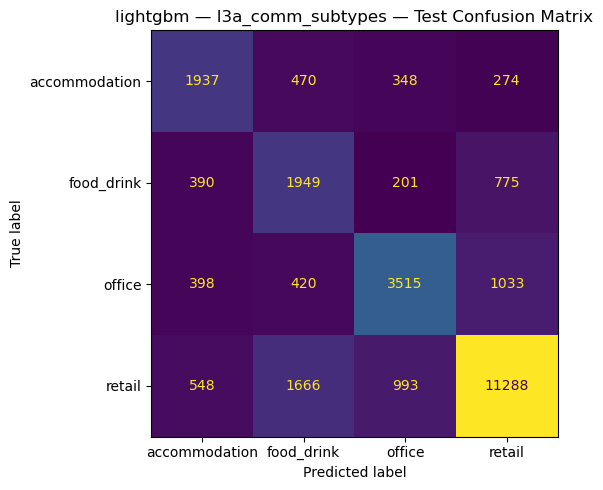


xgboost — VAL
  Macro F1           : 0.6411
  Weighted F1        : 0.7144
               precision    recall  f1-score   support

accommodation     0.5967    0.6344    0.6150      1581
   food_drink     0.4203    0.5631    0.4814      1639
       office     0.6766    0.6422    0.6589      2694
       retail     0.8406    0.7803    0.8094      7252

     accuracy                         0.7075     13166
    macro avg     0.6335    0.6550    0.6411     13166
 weighted avg     0.7254    0.7075    0.7144     13166


xgboost — TEST
  Macro F1           : 0.6470
  Weighted F1        : 0.7191
               precision    recall  f1-score   support

accommodation     0.5947    0.6345    0.6140      3029
   food_drink     0.4319    0.5659    0.4899      3315
       office     0.6857    0.6631    0.6742      5366
       retail     0.8420    0.7807    0.8102     14495

     accuracy                         0.7125     26205
    macro avg     0.6385    0.6610    0.6470     26205
 weighted avg     0

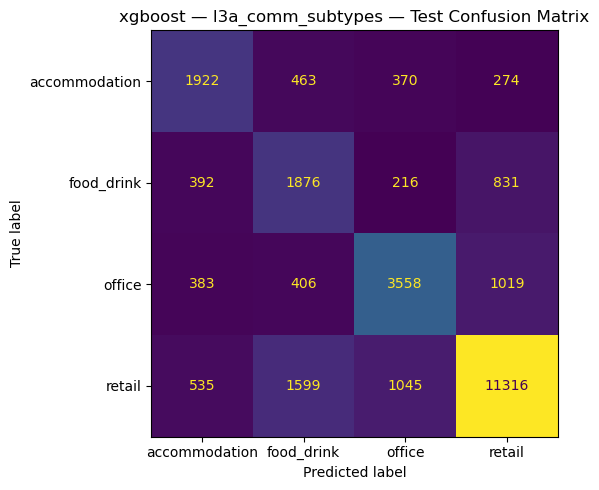


MODEL COMPARISON — l3a_comm_subtypes — TEST SET
Model                  Macro F1   Weighted F1
---------------------------------------------
lightgbm                 0.6495        0.7204
xgboost                  0.6470        0.7191


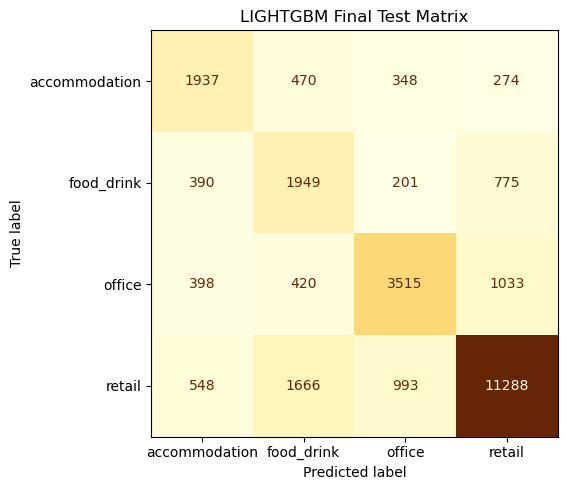

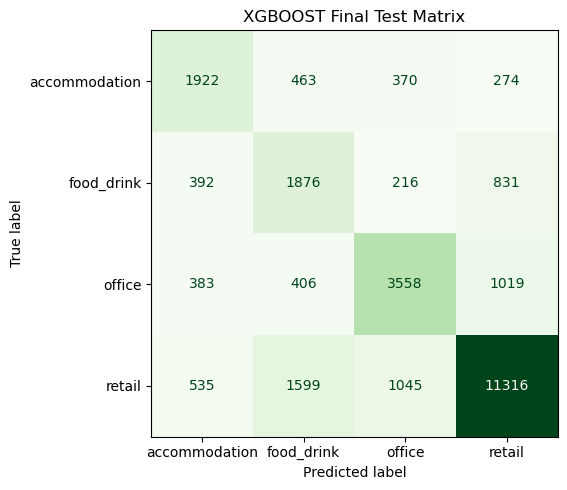

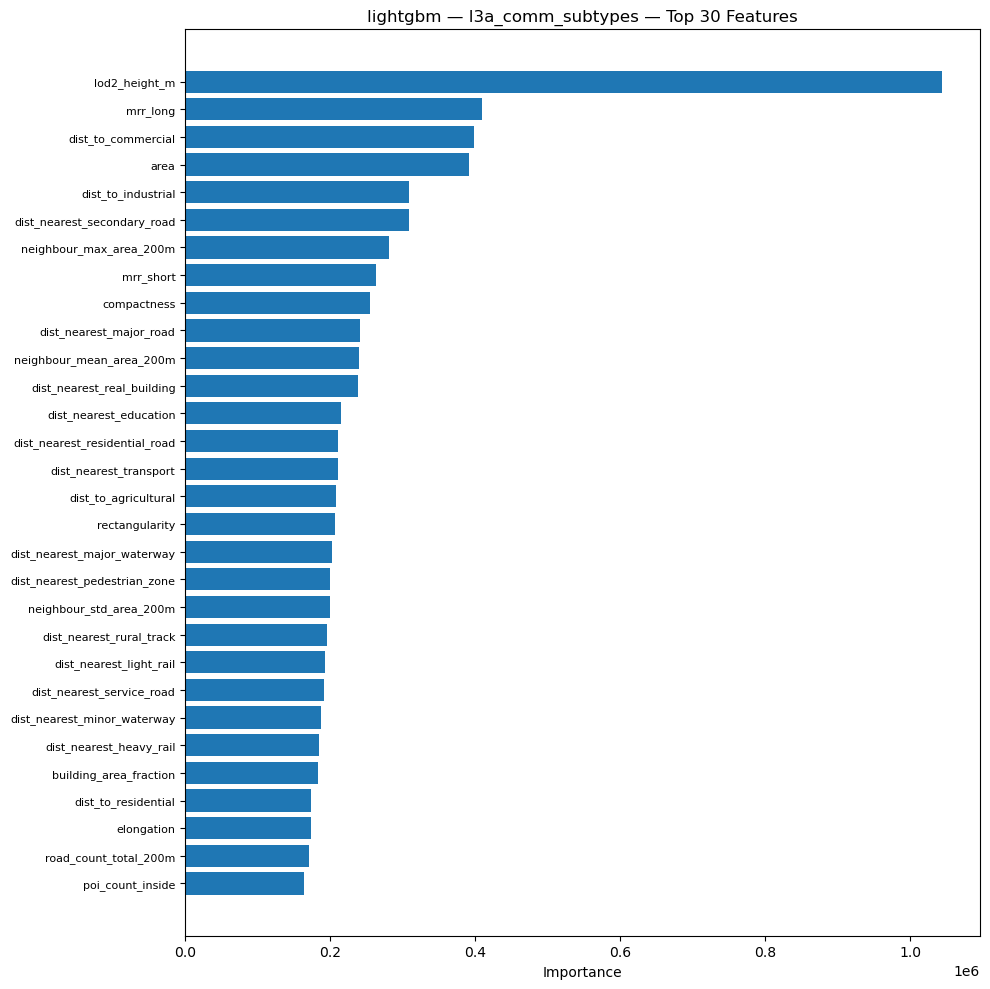

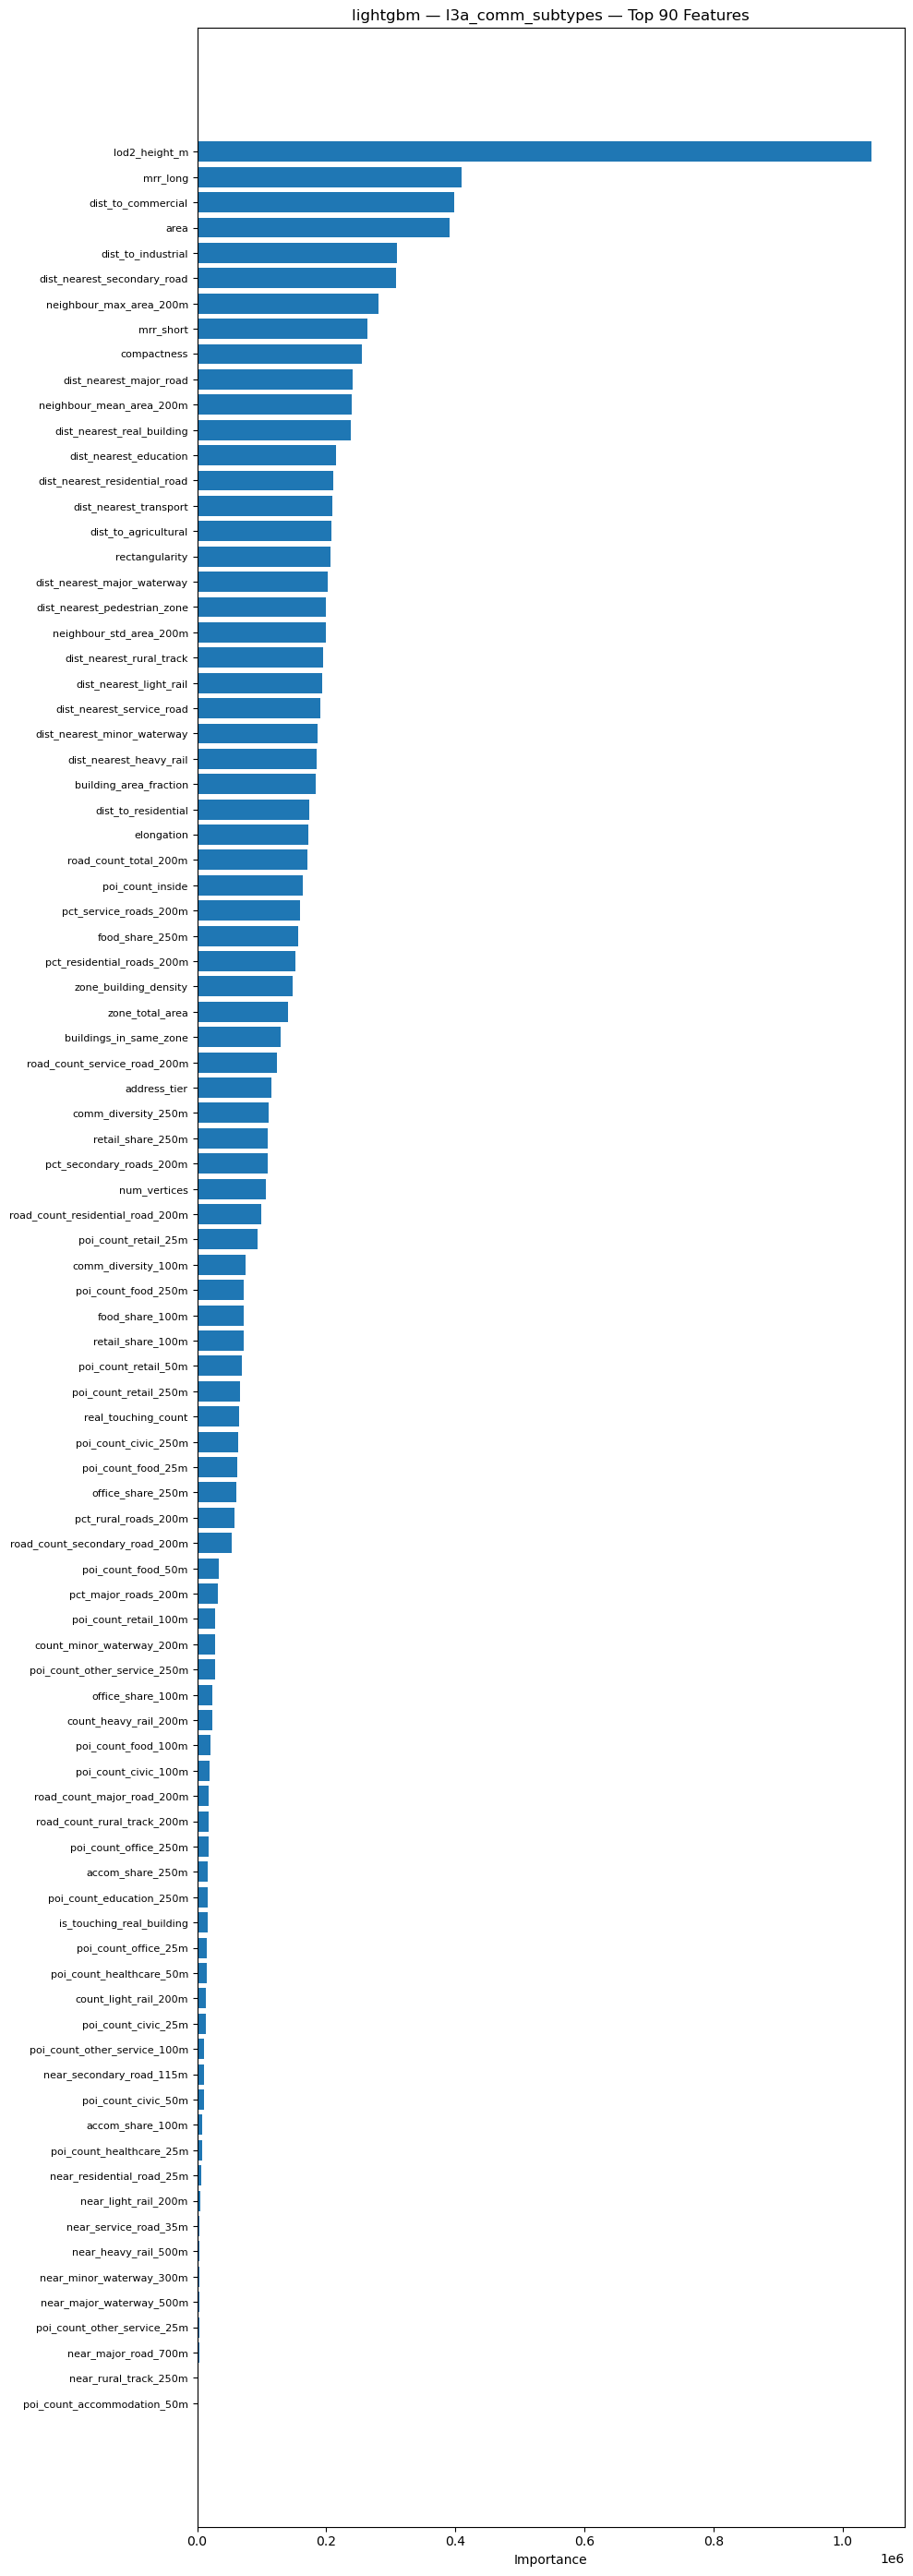

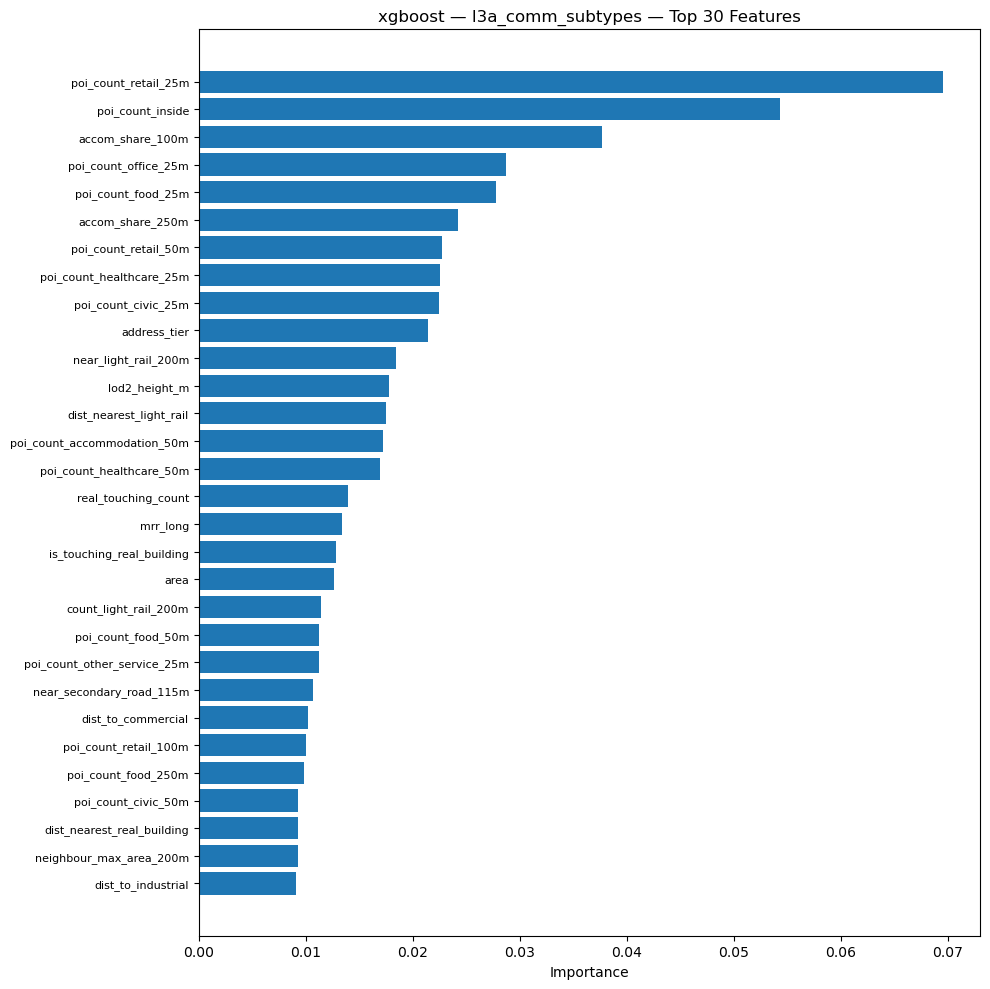

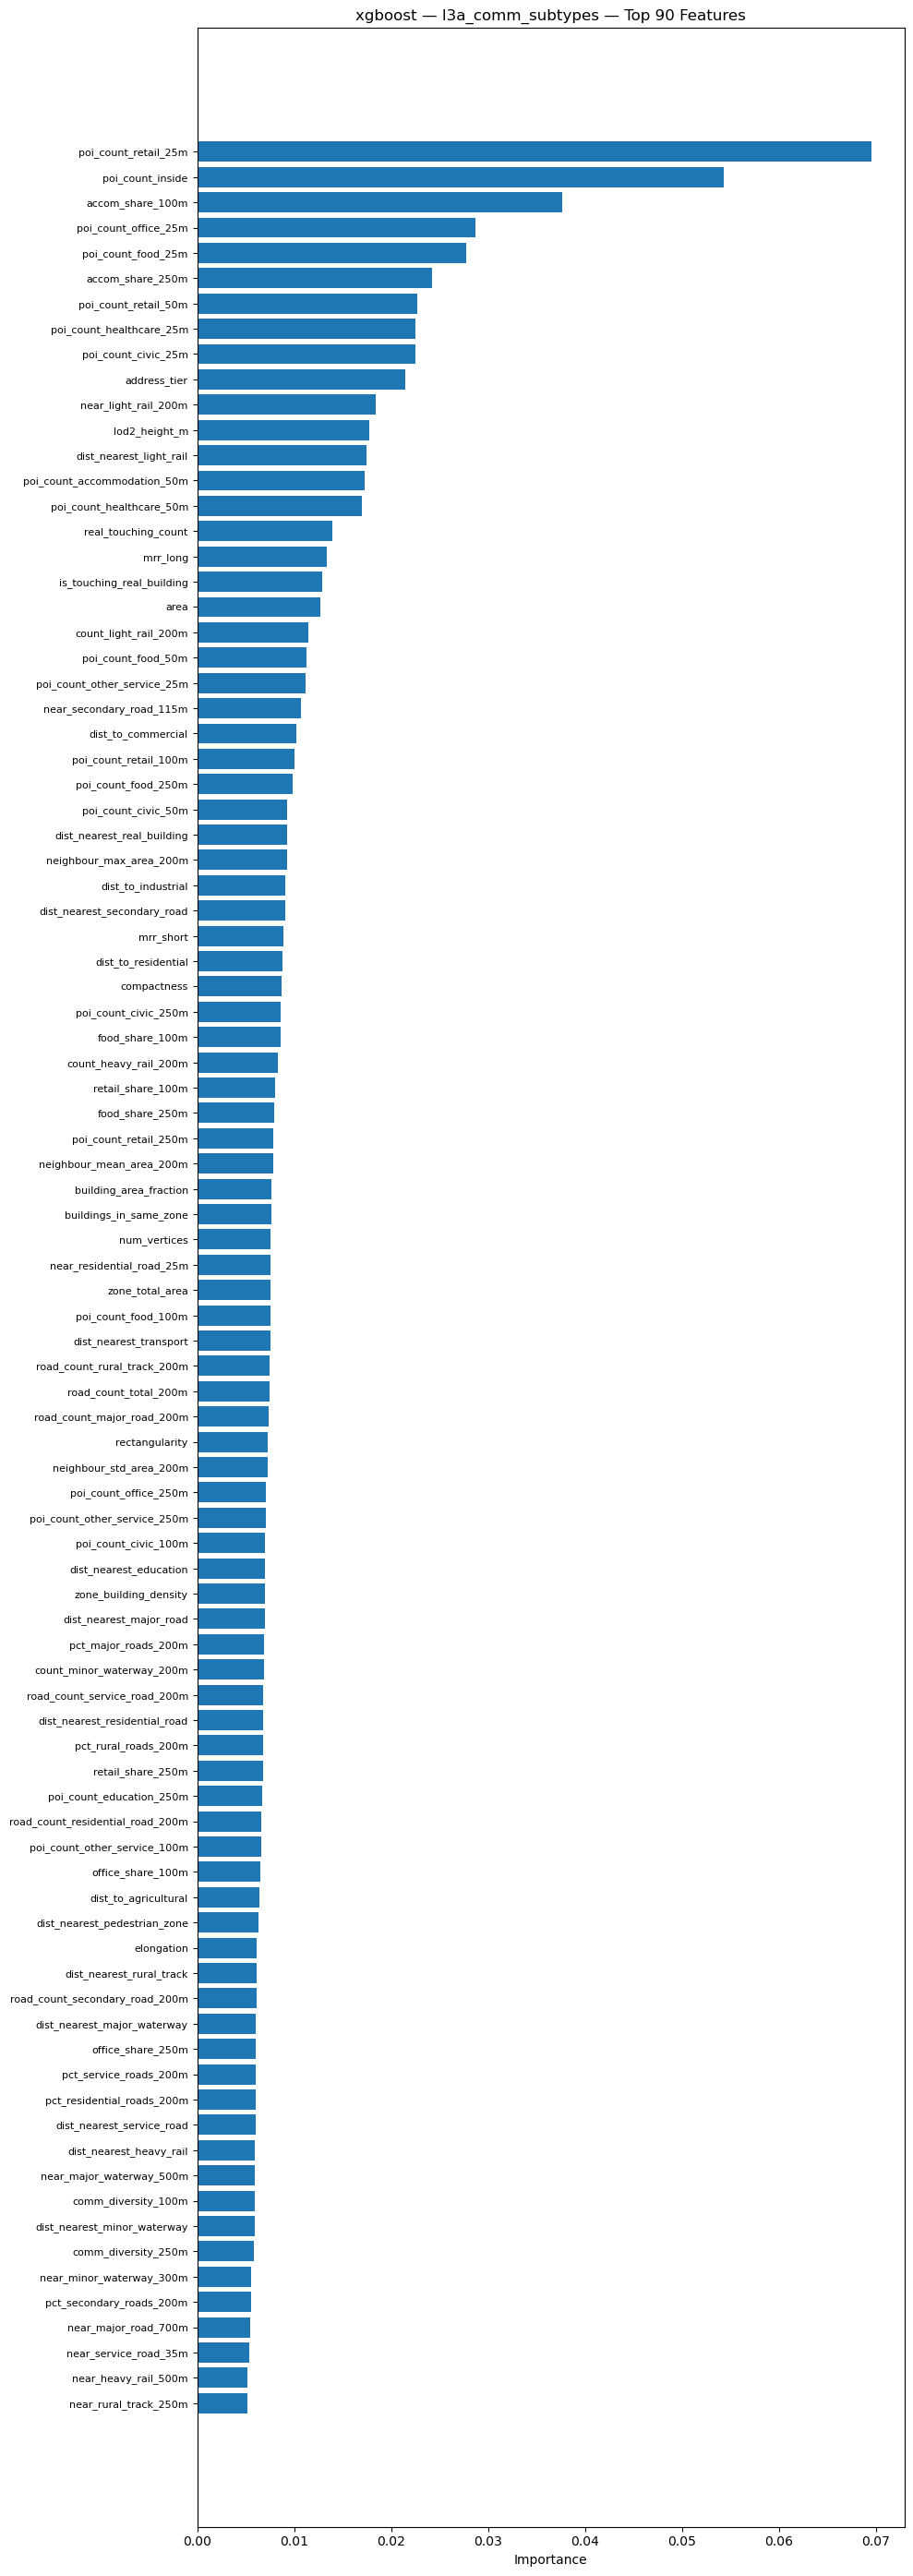

In [8]:
print(f"\n{'='*60}\nFINAL HOLDOUT TEST SET EVALUATION\n{'='*60}")
for model_name, model in trained_models.items():
    all_results[model_name] = evaluate(model, X_val, y_val, X_test, y_test, classes, model_name, LEVEL)

print(f"\n{'='*60}")
print(f"MODEL COMPARISON — {LEVEL} — TEST SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Macro F1':>10} {'Weighted F1':>13}")
print("-" * 45)
for model_name, res in all_results.items():
    print(f"{model_name:<20} {res['test']['macro_f1']:>10.4f} {res['test']['weighted_f1']:>13.4f}")

# Print Confusion Matrices on Unseen Test Set
for model_name, model in trained_models.items():
    test_preds = model.predict(X_test).astype(int)
    cm = confusion_matrix(y_test, test_preds)
    fig, ax = plt.subplots(figsize=(6, 5))
    cmap_color = 'YlOrBr' if model_name == 'lightgbm' else 'Greens'
    ConfusionMatrixDisplay(cm, display_labels=classes).plot(ax=ax, cmap=cmap_color, colorbar=False)
    ax.set_title(f'{model_name.upper()} Final Test Matrix')
    plt.tight_layout()
    plt.show()

# Print Feature Importances
def plot_feature_importance(model, model_name, feature_cols, level, top_n=30):
    if hasattr(model, 'feature_importances_'):
        imp = model.feature_importances_
        idx  = np.argsort(imp)[::-1][:top_n]
        fig, ax = plt.subplots(figsize=(10, top_n * 0.3 + 1))
        ax.barh(range(top_n), imp[idx][::-1])
        ax.set_yticks(range(top_n))
        ax.set_yticklabels([feature_cols[i] for i in idx[::-1]], fontsize=8)
        ax.set_title(f'{model_name} — {level} — Top {top_n} Features')
        ax.set_xlabel('Importance')
        plt.tight_layout()
        plt.show()

for model_name, model in trained_models.items():
    plot_feature_importance(model, model_name, feature_cols, LEVEL)
    plot_feature_importance(model, model_name, feature_cols, LEVEL, len(feature_cols))

In [9]:
print(f"\n{'='*60}")
print(f"MODEL COMPARISON — {LEVEL} — TEST SET")
print(f"{'='*60}")
print(f"{'Model':<20} {'Macro F1':>10} {'Weighted F1':>13}")
print("-" * 45)

for model_name, res in all_results.items():
    mf1 = res['test']['macro_f1']
    wf1 = res['test']['weighted_f1']
    print(f"{model_name:<20} {mf1:>10.4f} {wf1:>13.4f}")

# Save results to JSON for later aggregation
results_path = os.path.join(MODEL_DIR, f'{LEVEL}_results_height.json')
# Make results JSON-serialisable
serialisable = {
    m: {s: {k: v for k, v in r.items() if k != 'report'}
        for s, r in res.items()}
    for m, res in all_results.items()
}
with open(results_path, 'w') as f:
    json.dump(serialisable, f, indent=2)
print(f"\nResults saved → {results_path}")


MODEL COMPARISON — l3a_comm_subtypes — TEST SET
Model                  Macro F1   Weighted F1
---------------------------------------------
lightgbm                 0.6495        0.7204
xgboost                  0.6470        0.7191

Results saved → /fast/home/o-olajuyigbe/osm_project/data/models/l3a_comm_subtypes_results_height.json


In [11]:
# =====================================================================
# FINAL PRODUCTION ROLLOUT (100% DATA - FIXED ITERATIONS)
# =====================================================================
BEST_MODEL_NAME = 'lightgbm'  # Change to 'xgboost' if XGBoost performed better

print(f"Preparing final production model: {BEST_MODEL_NAME.upper()} on 100% of data")

# 1. Combine ALL data splits (100% of available data)
X_production_train = np.vstack([X_train, X_val, X_test])
y_production_train = np.concatenate([y_train, y_val, y_test])

# 2. Recompute balanced weights on the entire dataset
prod_weights = get_sample_weights(
    y_production_train,
    minority_boost=final_minority_boost_lgb if BEST_MODEL_NAME == 'lightgbm' else final_minority_boost_xgb
)

print(f"100% Production training pool : {X_production_train.shape[0]:,} rows")
print(f"Minority class instances      : {np.bincount(y_production_train)}")

# 3. Extract the optimal tree count from the previously trained Unified Base Model
best_unified_model = trained_models[BEST_MODEL_NAME]

if BEST_MODEL_NAME == 'lightgbm':
    # LightGBM uses 'best_iteration_'
    optimal_trees = best_unified_model.best_iteration_
    production_trees = int(optimal_trees * 1.05)
    print(f"🎯 Optimal trees extracted from unified model: {production_trees}")
    
    prod_model = lgb.LGBMClassifier(
        objective='multiclass', num_class=len(classes), metric='multi_logloss',
        boosting_type='gbdt', 
        n_estimators=production_trees, # HARDCODED EXACT TREE COUNT
        importance_type='gain', n_jobs=-1, random_state=42, verbosity=-1,
        **best_lgb_params
    )
    # Train without early stopping or eval_sets
    prod_model.fit(
        X_production_train, y_production_train,
        sample_weight=prod_weights
    )

elif BEST_MODEL_NAME == 'xgboost':
    # XGBoost uses 'best_iteration'
    optimal_trees = best_unified_model.best_iteration
    production_trees = int(optimal_trees * 1.05)
    print(f"🎯 Optimal trees extracted from unified model: {production_trees}")
    
    prod_model = xgb.XGBClassifier(
        objective='multi:softprob', num_class=len(classes), eval_metric='mlogloss',
        n_estimators=production_trees, importance_type='gain',
        tree_method='hist', device='cuda', n_jobs=-1, random_state=42,
        **best_xgb_params
    )
    # Train without early stopping or eval_sets
    prod_model.fit(
        X_production_train, y_production_train,
        sample_weight=prod_weights,
        verbose=False
    )

production_save_path = os.path.join(MODEL_DIR, f'{LEVEL}_lgb_PRODUCTION_FINAL_height.pkl')
joblib.dump(prod_model, production_save_path)
print(f"\n{'='*60}\n✅ ULTIMATE PRODUCTION MODEL DEPLOYED!\n   Saved model to: {production_save_path}\n{'='*60}")

Preparing final production model: LIGHTGBM on 100% of data
100% Production training pool : 263,542 rows
Minority class instances      : [ 30622  32634  55086 145200]
🎯 Optimal trees extracted from unified model: 2766

✅ ULTIMATE PRODUCTION MODEL DEPLOYED!
   Saved model to: /fast/home/o-olajuyigbe/osm_project/data/models/l3a_comm_subtypes_lgb_PRODUCTION_FINAL_height.pkl
